# Task 4: Pick the right chart five times

Each question uses a chart chosen for the comparison it asks about.


In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = Path("data")
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GREY, QUIET = "#b8b8b8", "#cfceca"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e1", "axes.titleweight": "bold",
})

mpg = pd.read_csv(DATA / "mpg.csv")
print(f"Horsepower is missing for {mpg['horsepower'].isna().sum()} cars.")
year_mpg = mpg.groupby("model_year", as_index=False)["mpg"].mean()


Horsepower is missing for 6 cars.


C:\Users\talha\AppData\Local\Temp\ipykernel_16648\3815835262.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([mpg.loc[mpg["origin"] == origin, "mpg"] for origin in origins], labels=[o.title() for o in origins], patch_artist=True)


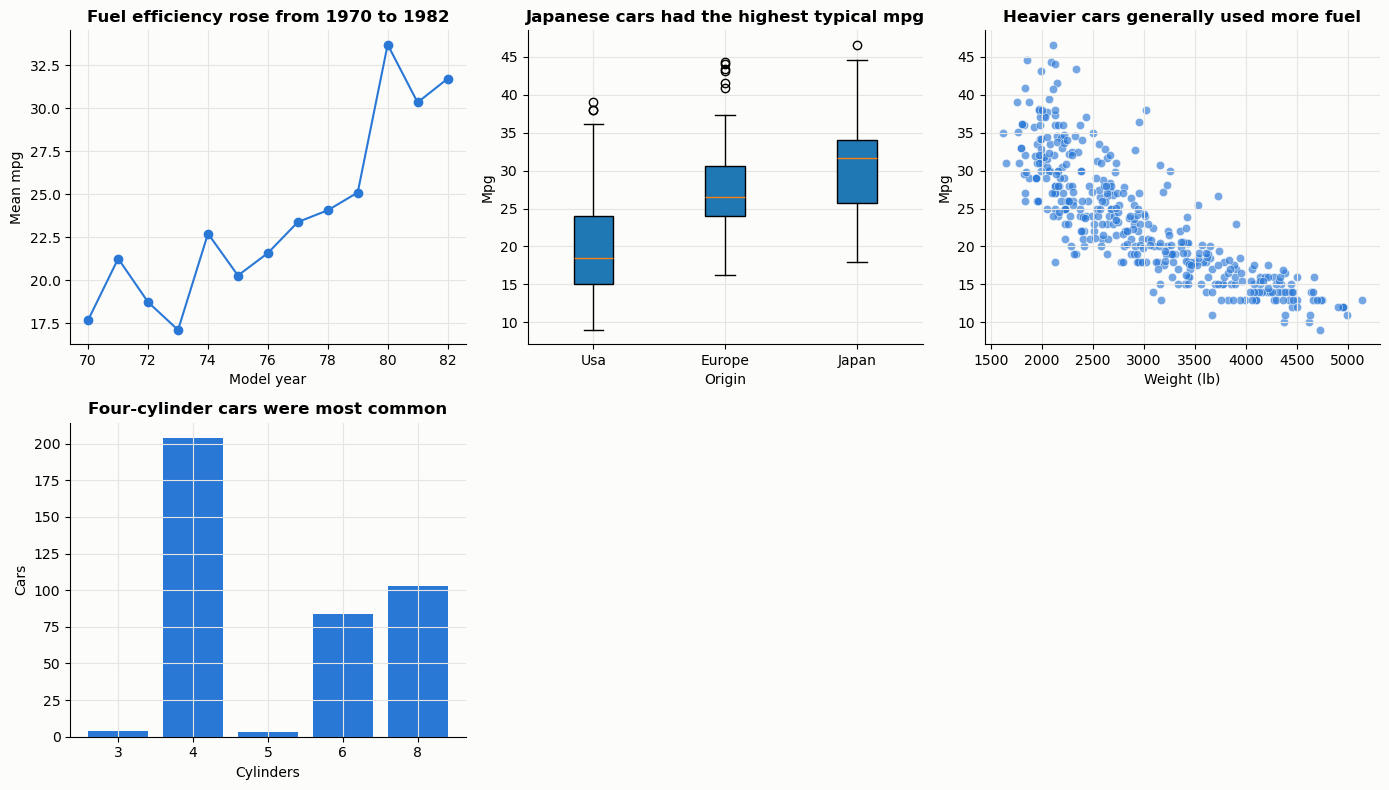

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flat
axes[0].plot(year_mpg["model_year"], year_mpg["mpg"], marker="o", color=BLUE)
axes[0].set_title("Fuel efficiency rose from 1970 to 1982"); axes[0].set_xlabel("Model year"); axes[0].set_ylabel("Mean mpg")
origins = ["usa", "europe", "japan"]
axes[1].boxplot([mpg.loc[mpg["origin"] == origin, "mpg"] for origin in origins], labels=[o.title() for o in origins], patch_artist=True)
axes[1].set_title("Japanese cars had the highest typical mpg"); axes[1].set_xlabel("Origin"); axes[1].set_ylabel("Mpg")
axes[2].scatter(mpg["weight"], mpg["mpg"], alpha=0.65, color=BLUE, edgecolor="#fcfcfb", linewidth=0.5)
axes[2].set_title("Heavier cars generally used more fuel"); axes[2].set_xlabel("Weight (lb)"); axes[2].set_ylabel("Mpg")
counts = mpg["cylinders"].value_counts().sort_index()
axes[3].bar(counts.index.astype(str), counts.values, color=BLUE)
axes[3].set_title("Four-cylinder cars were most common"); axes[3].set_xlabel("Cylinders"); axes[3].set_ylabel("Cars")
for ax in axes[4:]: ax.set_visible(False)
fig.tight_layout(); plt.show()


### Questions 1-4: chart choices

The line chart fits an ordered year trend. The box plot compares distributions by origin. The scatter plot shows the relationship between two numeric variables. The bar chart compares counts of discrete cylinder categories. Horsepower is not used, so its six missing values do not affect these charts.


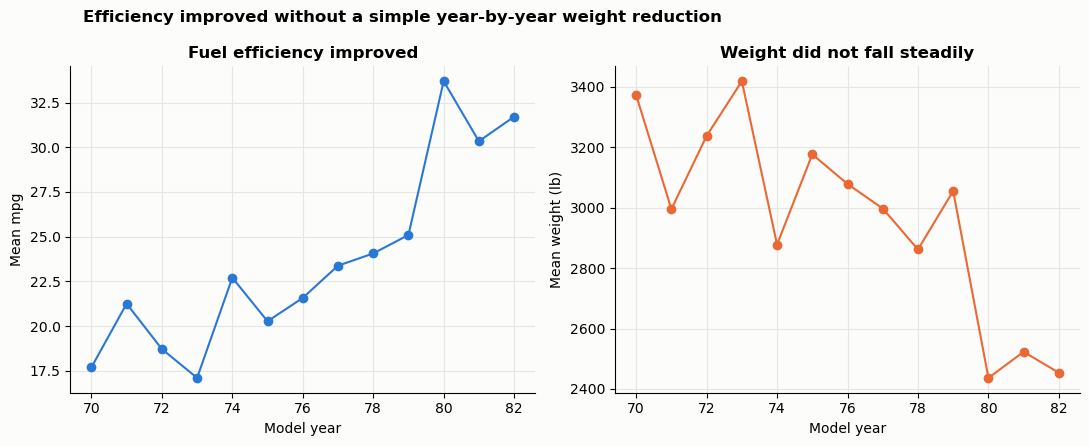

In [5]:
year_weight = mpg.groupby("model_year", as_index=False)["weight"].mean()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(year_mpg["model_year"], year_mpg["mpg"], marker="o", color=BLUE)
axes[0].set_title("Fuel efficiency improved"); axes[0].set_xlabel("Model year"); axes[0].set_ylabel("Mean mpg")
axes[1].plot(year_weight["model_year"], year_weight["weight"], marker="o", color=ORANGE)
axes[1].set_title("Weight did not fall steadily"); axes[1].set_xlabel("Model year"); axes[1].set_ylabel("Mean weight (lb)")
fig.suptitle("Efficiency improved without a simple year-by-year weight reduction", x=0.08, ha="left", fontweight="bold"); fig.tight_layout(); plt.show()


### Question 5: interpretation and redraw

The two-panel chart is a redraw of the weakest first chart. Showing mpg and weight trends side by side makes the proposed explanation testable without a dual y-axis. Fuel efficiency improved substantially, but mean weight did not decline in a matching, steady way. Weight is related to mpg across individual cars, but weight reduction alone does not explain the improvement.
